In [1]:
import os
import pandas as pd

In [2]:
def get_csv_file_info(folder_path):
    """
    Go through each CSV file in a folder and return a DataFrame with file paths and row counts.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing CSV files
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with two columns:
        - col1: file path (relative or absolute)
        - col2: row count
    """
    import glob
    import csv
    
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    file_info = []
    
    for csv_file in csv_files:
        try:
            # Count rows properly handling CSV format (quoted fields with newlines)
            with open(csv_file, 'r', encoding='utf-8') as f:
                reader = csv.reader(f)
                row_count = sum(1 for row in reader) - 1  # Subtract 1 for header
            file_info.append({
                'col1': csv_file,
                'col2': row_count
            })
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")
            file_info.append({
                'col1': csv_file,
                'col2': 0
            })
    
    # Create DataFrame
    result_df = pd.DataFrame(file_info)
    return result_df.sort_values(by='col2', ascending=False).reset_index(drop=True)

# run func
folder_path = "../data/raw/13998/v35_data_processing"
csv_info_df = get_csv_file_info(folder_path)
csv_info_df


,col1,col2
0,../data/raw/13998/v35_data_processing/s71_bt1x...,233479
1,../data/raw/13998/v35_data_processing/we3_bt1x...,208903
2,../data/raw/13998/v35_data_processing/we1_bt1x...,208903
3,../data/raw/13998/v35_data_processing/eb1_bt1x...,201735
4,../data/raw/13998/v35_data_processing/eb3_bt1x...,201735
5,../data/raw/13998/v35_data_processing/vm1_bt1x...,180231
6,../data/raw/13998/v35_data_processing/vm3_bt1x...,180231
7,../data/raw/13998/v35_data_processing/eg3_bt1x...,141319
8,../data/raw/13998/v35_data_processing/xf3_bt1x...,137223
9,../data/raw/13998/v35_data_processing/xf1_bt1x...,137223


In [3]:
"""CSV file parsing with header detection."""

import io
import logging
import os
from dataclasses import dataclass, field

import pandas as pd

logger = logging.getLogger(__name__)


@dataclass
class ParsedFile:
    """Result of parsing a CSV file."""

    filename: str
    dataframe: pd.DataFrame
    headers: list[str] = field(default_factory=list)
    units: list[str] = field(default_factory=list)
    is_valid: bool = True
    error: str | None = None
    row_count: int = 0


class CSVParser:
    """
    Parse CSV files with specialized header detection.

    Handles RSP-format CSV files with metadata rows:
    - #HEADER
    - #TITLES (column names)
    - #UNITS
    - #DATATYPES
    - #DATA (actual data starts here)
    """

    # Known metadata markers
    MARKERS = {"#HEADER", "#TITLES", "#UNITS", "#DATATYPES", "#DATA"}

    def parse(self, filepath: str) -> ParsedFile:
        """
        Parse CSV file from filepath and return ParsedFile.

        Args:
            filepath: Path to the CSV file

        Returns:
            ParsedFile with DataFrame and metadata
        """
        filename = os.path.basename(filepath)
        try:
            # Read file content
            with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
                text = f.read()
            
            lines = text.strip().split("\n")

            # Find data start and extract metadata
            data_start_idx = 0
            headers: list[str] = []
            units: list[str] = []

            for i, line in enumerate(lines):
                stripped = line.strip()
                if stripped == "#DATA":
                    data_start_idx = i + 1
                    break
                elif stripped == "#TITLES" and i + 1 < len(lines):
                    # Next line contains headers
                    header_line = lines[i + 1]
                    headers = [h.strip() for h in header_line.split(",")]
                elif stripped == "#UNITS" and i + 1 < len(lines):
                    # Next line contains units
                    unit_line = lines[i + 1]
                    units = [u.strip() for u in unit_line.split(",")]

            # If no #DATA marker found, assume data starts at first non-marker line
            if data_start_idx == 0:
                for i, line in enumerate(lines):
                    stripped = line.strip()
                    if stripped and not stripped.startswith("#"):
                        # Check if this looks like a header row
                        if i == 0 or not any(c.isdigit() for c in stripped.split(",")[0]):
                            headers = [h.strip() for h in stripped.split(",")]
                            data_start_idx = i + 1
                        else:
                            data_start_idx = i
                        break

            # Parse data section
            data_text = "\n".join(lines[data_start_idx:])
            df = pd.read_csv(
                io.StringIO(data_text),
                header=None,
                dtype=float,
                on_bad_lines="warn",
            )

            # Assign headers if we have them and they match column count
            if headers and len(headers) == len(df.columns):
                df.columns = headers
            elif headers:
                # Pad or truncate headers to match column count
                if len(headers) < len(df.columns):
                    headers.extend([f"col_{i}" for i in range(len(headers), len(df.columns))])
                df.columns = headers[: len(df.columns)]

            logger.info(f"Parsed {filename}: {len(df)} rows, {len(df.columns)} columns")

            return ParsedFile(
                filename=filename,
                dataframe=df,
                headers=list(df.columns),
                units=units,
                is_valid=True,
                row_count=len(df),
            )

        except Exception as e:
            logger.error(f"Failed to parse {filename}: {e}")
            return ParsedFile(
                filename=filename,
                dataframe=pd.DataFrame(),
                is_valid=False,
                error=str(e),
            )

In [4]:
parser = CSVParser()
csv_file = csv_info_df.iloc[0]['col1']
parsed = parser.parse(csv_file)
df = parsed.dataframe
df

,,,001_1 LF LCA OtrBJ P_UG_X Force,002_2 LF LCA OtrBJ P_UG_Y Force,003_3 LF LCA OtrBJ P_UG_Z Force,004_4 LF ShockLwBsh P_UG_X Force,005_5 LF ShockLwBsh P_UG_Y Force,006_6 LF ShockLwBsh P_UG_Z Force,007_7 LF LCABushingF P_UG_X Force,008_8 LF LCABushingF P_UG_Y Force,...,012_12 LF LCABushingR P_UG_Z Force,013_13 LF ShockLwBsh P_UG_X Momt,014_14 LF ShockLwBsh P_UG_Y Momt,015_15 LF ShockLwBsh P_UG_Z Momt,016_16 LF LCABushingF P_UG_X Momt,017_17 LF LCABushingF P_UG_Y Momt,018_18 LF LCABushingF P_UG_Z Momt,019_19 LF LCABushingR P_UG_X Momt,020_20 LF LCABushingR P_UG_Y Momt,021_21 LF LCABushingR P_UG_Z Momt
0,1.0,0.000,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0
1,2.0,0.001,-99.62,548.5,4277.0,10.79,-2048.0,-6572.0,-25.15,217.2,...,976.5,422.4,-1180.0,903.6,-74.61,-2441.0,675.0,-376.8,584.0,-323.7
2,3.0,0.002,292.70,-279.9,8756.0,40.43,-3599.0,-11550.0,-64.96,1181.0,...,2632.0,1427.0,189.5,1307.0,-1086.00,896.1,2037.0,-863.5,7368.0,-1424.0
3,4.0,0.003,282.40,-1532.0,9970.0,21.06,-4390.0,-13320.0,-147.20,2008.0,...,2886.0,461.5,-1894.0,1520.0,-1553.00,-2041.0,2486.0,-1103.0,6197.0,-1968.0
4,5.0,0.004,372.30,-2833.0,8234.0,-35.63,-4074.0,-11670.0,-229.00,2504.0,...,2422.0,-1689.0,-3700.0,1132.0,-1083.00,-1854.0,3123.0,-1331.0,1504.0,-3324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233467,233468.0,233.467,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0
233468,233469.0,233.468,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0
233469,233470.0,233.469,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0
233470,233471.0,233.470,303.30,-2849.0,9446.0,67.50,-3974.0,-12910.0,-264.00,2446.0,...,2623.0,20370.0,-2268.0,-542.4,4343.00,-1383.0,2310.0,5853.0,4359.0,-3008.0


In [5]:
def get_event(df,cols=[2,3]):
    """
    Get event data from a DataFrame.
    
    Args:
        df: DataFrame
        cols: list of column indices to get
        
    Returns:
        Tuple consisting of all rows in col 2 and all rows in col 3
    """ 
    col2 = df.iloc[:, cols[0]].to_numpy()
    col3 = df.iloc[:, cols[1]].to_numpy()
    return (col2, col3)

raw_event = get_event(df)
x=raw_event[0]
y=raw_event[1]

### LTTB Implementations

In [6]:
"""LTTB (Largest Triangle Three Buckets) downsampling algorithm."""

import logging

import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)


class LTTBDownsampler:
    """
    Implement LTTB algorithm for time-series downsampling.

    LTTB preserves the visual shape of the data while reducing points.
    Uses hybrid approach: extrema-preserving + density-aware LTTB.
    """

    def __init__(self, target_points: int = 5000, min_prominence: float = 0.0):
        """
        Initialize downsampler.

        Args:
            target_points: Target number of points after downsampling
            min_prominence: Minimum prominence of extrema to force-keep (0.0 = keep all extrema)
        """
        self.target_points = target_points
        self.min_prominence = min_prominence

    def downsample(
        self,
        event: tuple,
    ) -> pd.DataFrame:
        """
        Downsample using LTTB algorithm.

        Args:
            event: Tuple where event[0] is x values and event[1] is y values

        Returns:
            Downsampled DataFrame with x and y columns
        """
        # Extract x and y from tuple
        x_data = event[0]
        y_data = event[1]
        
        # Convert to numpy arrays (handles pandas Series, lists, etc.)
        if hasattr(x_data, 'values'):
            x = x_data.values.astype(np.float64)
        else:
            x = np.array(x_data, dtype=np.float64)
            
        if hasattr(y_data, 'values'):
            y = y_data.values.astype(np.float64)
        else:
            y = np.array(y_data, dtype=np.float64)
        
        # Check if empty
        if len(x) == 0 or len(y) == 0:
            return pd.DataFrame(columns=["x", "y"])
        
        # Ensure x and y have the same length (take minimum if different)
        min_len = min(len(x), len(y))
        x = x[:min_len]
        y = y[:min_len]

        # Remove NaN values
        valid_mask = ~(np.isnan(x) | np.isnan(y))
        x = x[valid_mask]
        y = y[valid_mask]

        if len(x) <= self.target_points:
            # No downsampling needed
            return pd.DataFrame({"x": x, "y": y})

        # Apply hybrid LTTB
        indices = self._lttb_extrema_density(x, y, self.target_points)

        """ return pd.DataFrame({
            "x": x[indices],
            "y": y[indices],
        }) """
        return (x[indices],y[indices])

    def _find_extrema_indices(
        self,
        y: np.ndarray,
    ) -> np.ndarray:
        """
        Detect local maxima/minima with optional prominence threshold.
        Returns sorted array of indices that must be kept (excluding first/last).
        """
        n = len(y)
        if n < 3:
            return np.array([], dtype=np.int64)

        extrema = []
        for i in range(1, n - 1):
            y0, y1, y2 = y[i - 1], y[i], y[i + 1]
            is_max = (y1 > y0 and y1 > y2)
            is_min = (y1 < y0 and y1 < y2)
            if not (is_max or is_min):
                continue

            if self.min_prominence > 0:
                # Simple local prominence estimate: difference to nearest side
                prominence = min(abs(y1 - y0), abs(y1 - y2))
                if prominence < self.min_prominence:
                    continue

            extrema.append(i)

        return np.array(extrema, dtype=np.int64)

    def _lttb_density_segment(
        self,
        x: np.ndarray,
        y: np.ndarray,
        start_idx: int,
        end_idx: int,
        budget: int,
    ) -> np.ndarray:
        """
        Run density-aware LTTB on a segment [start_idx, end_idx] of points.
        Returns global indices of selected points inside (start_idx, end_idx)
        (start and end themselves are NOT included here; caller usually locks them).
        """
        # Nothing or too little to sample
        if budget <= 0 or end_idx - start_idx <= 1:
            return np.array([], dtype=np.int64)

        seg_n = end_idx - start_idx + 1

        # Precompute local density weights (basic: 1 + |Δy|)
        weights = np.ones(seg_n, dtype=np.float64)
        for i in range(seg_n - 1):
            dy = abs(y[start_idx + i + 1] - y[start_idx + i])
            weights[i] += dy

        # Cumulative weights for adaptive bucket boundaries
        cumw = np.zeros(seg_n + 1, dtype=np.float64)
        cumw[1:] = np.cumsum(weights)
        total_w = cumw[-1]

        if total_w == 0:
            # Fallback: equal-weight (degenerate) -> just pick evenly spaced
            step = max(1, (seg_n - 2) // budget)
            indices = [start_idx + i for i in range(1, seg_n - 1, step)][:budget]
            return np.array(indices, dtype=np.int64)

        # Helper: find index where cumw >= target
        def find_cumw_index(from_idx: int, target_w: float, upper: int) -> int:
            i = from_idx
            while i < upper and cumw[i] < target_w:
                i += 1
            return min(i, upper)

        selected_global = []
        prev_i = 0  # index in segment of previously chosen point (start of segment)

        # We will choose `budget` points between start and end
        for b in range(1, budget + 1):
            left_target = total_w * (b - 1) / budget
            right_target = total_w * b / budget

            # bucket [L, R) in segment indices (excluding end)
            L = find_cumw_index(prev_i + 1, left_target, seg_n - 1)
            R = find_cumw_index(L + 1, right_target, seg_n)

            if R <= L:
                R = min(L + 1, seg_n - 1)

            # centroid of next bucket (for triangle computation)
            next_L = R
            next_R = min(seg_n, R + max(1, (seg_n - 1) // budget))
            
            # Handle empty slice case
            if next_R <= next_L:
                # Use the last point in segment as centroid
                cx = x[start_idx + seg_n - 1]
                cy = y[start_idx + seg_n - 1]
            else:
                cx = np.mean(x[start_idx + next_L:start_idx + next_R])
                cy = np.mean(y[start_idx + next_L:start_idx + next_R])

            ax, ay = x[start_idx + prev_i], y[start_idx + prev_i]

            best_i = L
            best_area = -1.0

            for i in range(L, R):
                bx, by = x[start_idx + i], y[start_idx + i]
                # Twice triangle area (no 0.5 required)
                area = abs((ax - cx) * (by - ay) - (ax - bx) * (cy - ay))
                if area > best_area:
                    best_area = area
                    best_i = i

            selected_global.append(start_idx + best_i)
            prev_i = best_i

        return np.array(selected_global, dtype=np.int64)

    def _lttb_extrema_density(
        self,
        x: np.ndarray,
        y: np.ndarray,
        m: int,
    ) -> np.ndarray:
        """
        Hybrid algorithm:
        1) Find and lock in significant extrema + first + last.
        2) Between locked points, run density-aware LTTB to fill remaining budget.

        Args:
            x: X values (sorted by time)
            y: Y values
            m: Target number of points in output

        Returns:
            Indices of selected points
        """
        n = len(x)
        if m >= n or m <= 2:
            return np.arange(n)

        # Step 1: find mandatory indices (extrema + endpoints)
        extrema = self._find_extrema_indices(y)
        mandatory = np.sort(np.unique(np.concatenate([[0, n - 1], extrema])))

        if len(mandatory) >= m:
            # If too many mandatory points, pick a subset preserving endpoints
            if len(mandatory) == m:
                return mandatory
            # Keep endpoints and select from middle
            middle = mandatory[1:-1]
            keep_count = max(0, m - 2)
            selected_middle = middle[:keep_count] if len(middle) > keep_count else middle
            return np.sort(np.concatenate([[0], selected_middle, [n - 1]]))

        remaining_budget = m - len(mandatory)

        # Step 2: distribute remaining budget across segments, proportional to length
        segment_lengths = []
        for i in range(len(mandatory) - 1):
            segment_lengths.append(mandatory[i + 1] - mandatory[i])

        total_len = sum(segment_lengths)
        if total_len == 0:
            return mandatory

        seg_budgets = []
        assigned = 0
        for L in segment_lengths[:-1]:
            b = int(round(remaining_budget * L / total_len))
            seg_budgets.append(b)
            assigned += b
        seg_budgets.append(max(0, remaining_budget - assigned))

        selected_indices = set(mandatory.tolist())

        # Step 3: run density-aware LTTB on each segment
        for s_idx, e_idx, b in zip(mandatory[:-1], mandatory[1:], seg_budgets):
            inner_selected = self._lttb_density_segment(x, y, int(s_idx), int(e_idx), b)
            for idx in inner_selected:
                selected_indices.add(int(idx))

        # Ensure we do not exceed m due to rounding; if so, trim some non-mandatory
        if len(selected_indices) > m:
            extra = len(selected_indices) - m
            # remove some non-mandatory, preferring inner ones
            removable = sorted(selected_indices - {0, n - 1})
            for idx in removable:
                if extra <= 0:
                    break
                selected_indices.remove(idx)
                extra -= 1

        # Final: sort and return
        return np.sort(np.array(list(selected_indices), dtype=np.int64))

    def downsample_by_factor(
        self,
        event: tuple,
        factor: float = 0.4,
    ) -> pd.DataFrame:
        """
        Downsample by a reduction factor.

        Args:
            event: Tuple where event[0] is x values and event[1] is y values
            factor: Reduction factor (0.4 = keep 40% of points)

        Returns:
            Downsampled DataFrame
        """
        # Get length from x or y (they should be same length)
        data_length = len(event[0]) if len(event[0]) > 0 else len(event[1])
        target = max(100, int(data_length * factor))
        original_target = self.target_points
        self.target_points = target

        try:
            return self.downsample(event)
        finally:
            self.target_points = original_target



In [7]:
# Downsample using the tuple
downsampler = LTTBDownsampler(target_points=5000)
lttb_base_5000 = downsampler.downsample(raw_event)

In [8]:
import numpy as np
import pandas as pd

class _LTTB2DDownsampler:
    """
    Simple 2D-aware LTTB downsampler for time-series or XY loops.
    Preserves visual shape including thin elongated loops.
    """

    def __init__(self, target_points=5000, curvature_threshold=0.01):
        """
        Args:
            target_points: number of points to keep
            curvature_threshold: minimum curvature to force-keep points
        """
        self.target_points = target_points
        self.curvature_threshold = curvature_threshold

    def downsample(self, event):
        """
        Args:
            event: tuple (x, y)
        Returns:
            pd.DataFrame with 'x' and 'y'
        """
        x, y = np.array(event[0], dtype=np.float64), np.array(event[1], dtype=np.float64)
        n = len(x)
        if n <= self.target_points:
            return pd.DataFrame({"x": x, "y": y})

        # Remove NaNs
        valid = ~(np.isnan(x) | np.isnan(y))
        x, y = x[valid], y[valid]
        n = len(x)

        # Normalize axes for long/thin loops
        x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
        y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

        # Find mandatory points: endpoints + curvature-based
        mandatory = {0, n - 1}

        # Compute simple curvature
        dx = np.diff(x_norm)
        dy = np.diff(y_norm)
        curvature = np.abs(np.diff(dy) - np.diff(dx))
        high_curv = np.where(curvature > self.curvature_threshold)[0] + 1
        mandatory.update(high_curv.tolist())
        mandatory = sorted(mandatory)

        # Compute LTTB points
        remaining_budget = self.target_points - len(mandatory)
        if remaining_budget <= 0:
            selected_indices = mandatory[:self.target_points]
            return pd.DataFrame({"x": x[selected_indices], "y": y[selected_indices]})

        # Distribute budget between segments
        segments = [(mandatory[i], mandatory[i+1]) for i in range(len(mandatory)-1)]
        seg_lengths = [end - start for start, end in segments]
        total_len = sum(seg_lengths)
        seg_budgets = [max(0, int(round(remaining_budget * l / total_len))) for l in seg_lengths]

        selected = set(mandatory)
        for (start, end), budget in zip(segments, seg_budgets):
            if budget <= 0 or end - start <= 1:
                continue
            seg_indices = self._lttb_segment(x_norm, y_norm, start, end, budget)
            selected.update(seg_indices)

        selected_indices = sorted(selected)[:self.target_points]
        return (x[selected_indices], y[selected_indices])

    def _lttb_segment(self, x, y, start, end, budget):
        """LTTB on a segment [start, end] using 2D triangle area"""
        seg_len = end - start + 1
        if seg_len <= 2 or budget <= 0:
            return []

        cum_w = np.cumsum([1.0] + list(np.sqrt(np.diff(x[start:end+1])**2 + np.diff(y[start:end+1])**2)))
        total_w = cum_w[-1]
        selected = []
        prev_idx = 0

        for b in range(1, budget + 1):
            # Find bucket boundaries
            target_l = total_w * (b - 1) / budget
            target_r = total_w * b / budget
            L = np.searchsorted(cum_w, target_l, side='left')
            R = np.searchsorted(cum_w, target_r, side='right')
            if R <= L:
                R = min(L+1, seg_len-1)

            ax, ay = x[start + prev_idx], y[start + prev_idx]
            cx, cy = np.mean(x[start+L:start+R]), np.mean(y[start+L:start+R])

            best_area = -1
            best_idx = L
            for i in range(L, R):
                bx, by = x[start + i], y[start + i]
                area = abs((ax - cx)*(by - ay) - (ax - bx)*(cy - ay))
                if area > best_area:
                    best_area = area
                    best_idx = i

            selected.append(start + best_idx)
            prev_idx = best_idx

        return selected


In [ ]:
import numpy as np
import pandas as pd


class LTTB2DInflectionDownsampler:
    """
    2D downsampler using:
      - Inflection points as topological anchors
      - Curvature-weighted segmentation  - [?] Does this miss any ciritcal points?
      - Canonical LTTB inside each segment

    Guarantees:
      - Index order preserved
      - Endpoints preserved
      - Exact output size
      - No mandatory-point explosion
    """

    def __init__(self, target_points=5000, inflection_eps=1e-6, point_budget=100):
        self.target_points = int(target_points)
        self.inflection_eps = float(inflection_eps)
        self.point_budget = int(point_budget)

    # ------------------------------------------------------------------

    def downsample(self, event):
        x = np.asarray(event[0], dtype=np.float64)
        y = np.asarray(event[1], dtype=np.float64)

        if len(x) <= self.target_points:
            return (x, y)

        # Remove NaNs
        valid = ~(np.isnan(x) | np.isnan(y))
        x, y = x[valid], y[valid]
        n = len(x)

        if n <= self.target_points:
            return (x, y)

        # Normalize for numeric stability
        x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
        y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

        # ------------------------------------------------------------------
        # 1. Inflection anchors (topological, NOT mandatory output points)
        # ------------------------------------------------------------------
        anchors = self._inflection_points(x_n, y_n)
        anchors = sorted({0, n - 1, *anchors})
        print(r"Number of anchors: ", len(anchors))

        # If target is tiny, fall back to endpoints + uniform sampling
        if self.target_points <= 2:
            idx = np.linspace(0, n - 1, self.target_points, dtype=int)
            return (x[idx], y[idx])

        # ------------------------------------------------------------------
        # 2. Build segments
        # ------------------------------------------------------------------
        segments = [(anchors[i], anchors[i + 1])
                    for i in range(len(anchors) - 1)
                    if anchors[i + 1] - anchors[i] > 1]

        if not segments:
            idx = np.linspace(0, n - 1, self.target_points, dtype=int)
            return (x[idx], y[idx])
        print(r"Number of segments: ", len(segments))

        # ------------------------------------------------------------------
        # 3. Curvature-weighted budget allocation
        # ------------------------------------------------------------------
        curvatures = np.array([
            self._segment_curvature(x_n, y_n, s, e)
            for s, e in segments
        ], dtype=np.float64)

        weights = curvatures + 1e-12

        # FIX #1: Anchor points are mandatory output points.
        # They define where the curve changes direction — without them
        # the polyline cuts corners and produces zig-zags.
        n_anchors = len(anchors)
        available = self.target_points - n_anchors
        if available <= 0:
            # More anchors than budget: subsample anchors, keep endpoints
            pick = np.linspace(0, n_anchors - 1, self.target_points, dtype=int)
            final_idx = np.array([anchors[i] for i in pick])
            return (x[final_idx], y[final_idx])

        n_seg = len(segments)
        min_budget = self.point_budget

        # Guarantee every segment gets at least min_budget points
        if available >= n_seg * min_budget:
            # Enough room: give each segment the floor, distribute the rest
            reserved = n_seg * min_budget
            extra = available - reserved
            raw_extra = extra * weights / weights.sum()
            budgets = np.floor(raw_extra).astype(int) + min_budget

            leftover = available - budgets.sum()
            for i in np.argsort(raw_extra - np.floor(raw_extra))[::-1][:leftover]:
                budgets[i] += 1
        else:
            # Very tight budget: spread what we have, but clamp to min_budget
            raw = available * weights / weights.sum()
            budgets = np.maximum(np.floor(raw).astype(int), min_budget)

            leftover = available - budgets.sum()
            if leftover > 0:
                for i in np.argsort(raw - budgets)[::-1][:leftover]:
                    budgets[i] += 1

        print(r"Point budget: ", budgets)

        # ------------------------------------------------------------------
        # 4. LTTB per segment
        # ------------------------------------------------------------------
        # FIX #1 cont'd: seed selected with ALL anchor points
        selected = set(anchors)

        for (start, end), budget in zip(segments, budgets):
            pts = self._lttb_segment(x_n, y_n, start, end, budget)
            selected.update(pts)

        final_idx = np.array(sorted(selected))[:self.target_points]
        return (x[final_idx], y[final_idx])

    # ==================================================================
    # Geometry helpers
    # ==================================================================

    def _inflection_points(self, x, y):
        """
        Detects inflection points via sign change of signed curvature.
        """
        dx = np.diff(x)
        dy = np.diff(y)

        cross = dx[:-1] * dy[1:] - dy[:-1] * dx[1:]
        mag = np.abs(cross)

        sign = np.sign(cross)
        infl = np.where(
            (sign[:-1] * sign[1:] < 0) &
            (mag[:-1] > self.inflection_eps) &
            (mag[1:] > self.inflection_eps)
        )[0] + 1

        return infl.tolist()

    # ------------------------------------------------------------------

    def _segment_curvature(self, x, y, start, end):
        """
        Integrated absolute curvature over a segment.
        """
        dx = np.diff(x[start:end])
        dy = np.diff(y[start:end])
        if len(dx) < 2:
            return 0.0
        return np.sum(np.abs(dx[:-1] * dy[1:] - dy[:-1] * dx[1:]))

    # ------------------------------------------------------------------

    def _lttb_segment(self, x, y, start, end, budget):
        """
        Canonical LTTB on (start, end), excluding endpoints.

        Invariants enforced:
          - Forward-only traversal (no backward jumps)
          - Point C = centroid of NEXT bucket (canonical LTTB look-ahead)
          - Last bucket uses inclusive upper edge (no dropped tail points)
        """
        candidates = np.arange(start + 1, end)
        if len(candidates) <= budget:
            return candidates.tolist()

        dx = np.diff(x[start:end + 1])
        dy = np.diff(y[start:end + 1])
        dist = np.sqrt(dx * dx + dy * dy)
        dist = np.insert(dist, 0, 0.0)
        cumdist = np.cumsum(dist)
        seg_len = len(cumdist)          # end - start + 1
        local_idx = np.arange(seg_len)

        total = cumdist[-1]
        edges = np.linspace(0, total, budget + 1)

        # Pre-compute bucket membership for next-bucket look-ahead
        # (avoids recomputing masks twice per iteration)
        def _bucket_mask(b_idx):
            """Mask for bucket b_idx, inclusive upper edge on last bucket."""
            lo = cumdist >= edges[b_idx]
            if b_idx == budget - 1:
                hi = cumdist <= edges[b_idx + 1]   # FIX #3: inclusive
            else:
                hi = cumdist < edges[b_idx + 1]
            return lo & hi

        selected = []
        prev = start

        for i in range(budget):
            rel_prev = prev - start

            # Forward-only guard: only consider points after prev
            mask = _bucket_mask(i) & (local_idx > rel_prev)
            bucket = np.where(mask)[0]

            if len(bucket) == 0:
                continue

            # Point A — previously selected point
            ax, ay = x[prev], y[prev]

            # FIX #2: Point C = centroid of NEXT bucket (canonical LTTB)
            # For the last bucket, use the segment endpoint.
            if i + 1 < budget:
                next_mask = _bucket_mask(i + 1)
                next_bucket = np.where(next_mask)[0]
                if len(next_bucket) > 0:
                    cx = x[start + next_bucket].mean()
                    cy = y[start + next_bucket].mean()
                else:
                    cx, cy = x[end], y[end]
            else:
                cx, cy = x[end], y[end]

            # Point B — every candidate in this bucket (vectorised)
            bx = x[start + bucket]
            by = y[start + bucket]

            area = np.abs(
                (ax - cx) * (by - ay) -
                (ax - bx) * (cy - ay)
            )

            best = bucket[np.argmax(area)]
            idx = start + best
            selected.append(idx)
            prev = idx

        return selected


In [10]:
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed


class TopologicalLTTB_DEP:
    """
    2D downsampler using:
      - Inflection points as topological anchors
      - Curvature-weighted segmentation
      - Canonical LTTB inside each segment

    Guarantees:
      - Index order preserved
      - Endpoints preserved
      - Exact output size
      - No mandatory-point explosion

    Improvements over baseline:
      1. Vectorised _lttb_segment (np.digitize, no per-iteration masking)
      2. Next-bucket centroid look-ahead (classic LTTB)
      3. Last-bucket inclusive edge (cumdist <= total)
      4. Adaptive inflection_eps (percentile-based)
      5. Empty-bucket redistribution (guarantees exact output size)
      6. Parallel segment processing (concurrent.futures)
    """

    def __init__(self, target_points=10000, inflection_eps=None, n_workers=None):
        """
        Args:
            target_points: Number of output points.
            inflection_eps: Absolute threshold for inflection detection.
                            If *None* (default), an adaptive threshold is
                            computed from the data (top 1 % of cross-product
                            magnitudes).
            n_workers:      Max threads for parallel segment processing.
                            None = min(num_segments, os.cpu_count()).
        """
        self.target_points = int(target_points)
        self.inflection_eps = inflection_eps  # None → adaptive
        self.n_workers = n_workers

    # ------------------------------------------------------------------

    def downsample(self, event):
        x = np.asarray(event[0], dtype=np.float64)
        y = np.asarray(event[1], dtype=np.float64)

        if len(x) <= self.target_points:
            return (x, y)

        # Remove NaNs
        valid = ~(np.isnan(x) | np.isnan(y))
        x, y = x[valid], y[valid]
        n = len(x)

        if n <= self.target_points:
            return (x, y)

        # Normalize for numeric stability
        x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
        y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

        # ------------------------------------------------------------------
        # 1. Inflection anchors (topological, NOT mandatory output points)
        # ------------------------------------------------------------------
        anchors = self._inflection_points(x_n, y_n)
        anchors = sorted({0, n - 1, *anchors})

        # If target is tiny, fall back to endpoints + uniform sampling
        if self.target_points <= 2:
            idx = np.linspace(0, n - 1, self.target_points, dtype=int)
            return (x[idx], y[idx])

        # ------------------------------------------------------------------
        # 2. Build segments
        # ------------------------------------------------------------------
        segments = [(anchors[i], anchors[i + 1])
                    for i in range(len(anchors) - 1)
                    if anchors[i + 1] - anchors[i] > 1]

        if not segments:
            idx = np.linspace(0, n - 1, self.target_points, dtype=int)
            return (x[idx], y[idx])

        # ------------------------------------------------------------------
        # 3. Curvature-weighted budget allocation
        # ------------------------------------------------------------------
        curvatures = np.array([
            self._segment_curvature(x_n, y_n, s, e)
            for s, e in segments
        ], dtype=np.float64)

        weights = curvatures + 1e-12
        available = self.target_points - 2  # endpoints fixed

        raw = available * weights / weights.sum()
        budgets = np.floor(raw).astype(int)

        leftover = available - budgets.sum()
        for i in np.argsort(raw - budgets)[::-1][:leftover]:
            budgets[i] += 1

        # ------------------------------------------------------------------
        # 4. LTTB per segment  (Improvement #6 — parallel processing)
        # ------------------------------------------------------------------
        selected = {0, n - 1}

        # Filter to segments that actually have work
        work_items = [
            (start, end, budget)
            for (start, end), budget in zip(segments, budgets)
            if budget > 0
        ]

        if len(work_items) > 1:
            max_workers = self.n_workers or min(len(work_items), 8)
            with ThreadPoolExecutor(max_workers=max_workers) as pool:
                futures = {
                    pool.submit(self._lttb_segment, x_n, y_n, s, e, b): (s, e, b)
                    for s, e, b in work_items
                }
                for fut in as_completed(futures):
                    selected.update(fut.result())
        else:
            for s, e, b in work_items:
                selected.update(self._lttb_segment(x_n, y_n, s, e, b))

        final_idx = np.array(sorted(selected))[:self.target_points]
        return (x[final_idx], y[final_idx])

    # ==================================================================
    # Geometry helpers
    # ==================================================================

    def _inflection_points(self, x, y):
        """
        Detects inflection points via sign change of signed curvature.

        Improvement #4 — Adaptive inflection_eps:
        If self.inflection_eps is None, threshold is set to the top 1 %
        of cross-product magnitudes (robust to varying scales / noise).
        """
        dx = np.diff(x)
        dy = np.diff(y)

        cross = dx[:-1] * dy[1:] - dy[:-1] * dx[1:]
        mag = np.abs(cross)

        # Adaptive eps: 1 % of the 90th-percentile magnitude
        eps = self.inflection_eps
        if eps is None:
            eps = np.percentile(mag, 90) * 0.01

        sign = np.sign(cross)
        infl = np.where(
            (sign[:-1] * sign[1:] < 0) &
            (mag[:-1] > eps) &
            (mag[1:] > eps)
        )[0] + 1

        return infl.tolist()

    # ------------------------------------------------------------------

    def _segment_curvature(self, x, y, start, end):
        """
        Integrated absolute curvature over a segment.
        """
        dx = np.diff(x[start:end])
        dy = np.diff(y[start:end])
        if len(dx) < 2:
            return 0.0
        return np.sum(np.abs(dx[:-1] * dy[1:] - dy[:-1] * dx[1:]))

    # ------------------------------------------------------------------

    def _lttb_segment(self, x, y, start, end, budget):
        """
        Canonical LTTB on (start, end), excluding endpoints.

        Improvements applied:
          #1 — Vectorised bucket assignment via np.digitize (no repeated
               mask creation inside the loop).
          #2 — Point C is the centroid of the *next* bucket (look-ahead).
          #3 — Last bucket uses inclusive upper edge (<=).
          #5 — Empty buckets are tracked; missed points are redistributed
               in a second pass so output size is guaranteed.
        """
        candidates = np.arange(start + 1, end)
        if len(candidates) <= budget:
            return candidates.tolist()

        # --- arc-length parameterisation ----------------------------------
        dx = np.diff(x[start:end + 1])
        dy = np.diff(y[start:end + 1])
        dist = np.sqrt(dx * dx + dy * dy)
        dist = np.insert(dist, 0, 0.0)
        cumdist = np.cumsum(dist)

        total = cumdist[-1]
        edges = np.linspace(0, total, budget + 1)

        # --- Improvement #1: vectorised bucket assignment -----------------
        # np.digitize returns bin index for each point; right=False means
        # edges[i] <= val < edges[i+1], which matches the original mask.
        bin_ids = np.digitize(cumdist, edges, right=False) - 1
        # Improvement #3: last bucket inclusive — points at cumdist == total
        # would fall into bin `budget`, clamp them back to last bucket.
        bin_ids = np.clip(bin_ids, 0, budget - 1)

        # Pre-compute per-bucket point lists (indices into cumdist / x,y
        # arrays relative to `start`).
        bucket_members = [[] for _ in range(budget)]  # type: list[list[int]]
        for local_idx, b in enumerate(bin_ids):
            bucket_members[b].append(local_idx)

        # --- main LTTB loop ----------------------------------------------
        selected = []
        prev = start         # global index of previously selected point
        skipped_budgets = 0  # Improvement #5: track empty-bucket misses

        for i in range(budget):
            bucket = np.asarray(bucket_members[i], dtype=np.intp)

            # Enforce forward-only: keep only points strictly after prev
            rel_prev = prev - start
            bucket = bucket[bucket > rel_prev]

            if len(bucket) == 0:
                skipped_budgets += 1
                continue

            # Point A — previously selected point
            ax, ay = x[prev], y[prev]

            # Improvement #2: Point C is centroid of the *next* bucket
            if i + 1 < budget:
                next_bucket = np.asarray(bucket_members[i + 1], dtype=np.intp)
                if len(next_bucket) > 0:
                    cx = x[start + next_bucket].mean()
                    cy = y[start + next_bucket].mean()
                else:
                    cx, cy = x[end], y[end]
            else:
                cx, cy = x[end], y[end]  # last bucket looks toward endpoint

            # Point B — every candidate in this bucket (vectorised)
            bx = x[start + bucket]
            by = y[start + bucket]

            area = np.abs(
                (ax - cx) * (by - ay) -
                (ax - bx) * (cy - ay)
            )

            best = bucket[np.argmax(area)]
            idx = start + best
            selected.append(idx)
            prev = idx

        # --- Improvement #5: redistribute missed budget -------------------
        if skipped_budgets > 0 and len(selected) < budget:
            already = set(selected)
            remaining = np.array(
                [c for c in candidates if c not in already], dtype=np.intp
            )
            if len(remaining) > 0:
                need = budget - len(selected)
                # Uniform pick from remaining candidates
                pick_idx = np.linspace(
                    0, len(remaining) - 1, min(need, len(remaining)), dtype=int
                )
                selected.extend(remaining[pick_idx].tolist())

        return selected


In [11]:
downsampler = LTTB2DInflectionDownsampler(target_points=5000)
lttb_2d_5000 = downsampler.downsample(raw_event)

Number of anchors:  128
Number of segments:  120
Point budget:  [100 100 100 100 100 258 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100 100
 100 100 100 100 100 100 100 100 100 100 100 100]


### Plot Events

In [12]:
events={
    "raw":raw_event,
    #"lttb_base_5000":lttb_base_5000,
    "lttb_2d_5000":lttb_2d_5000,
}

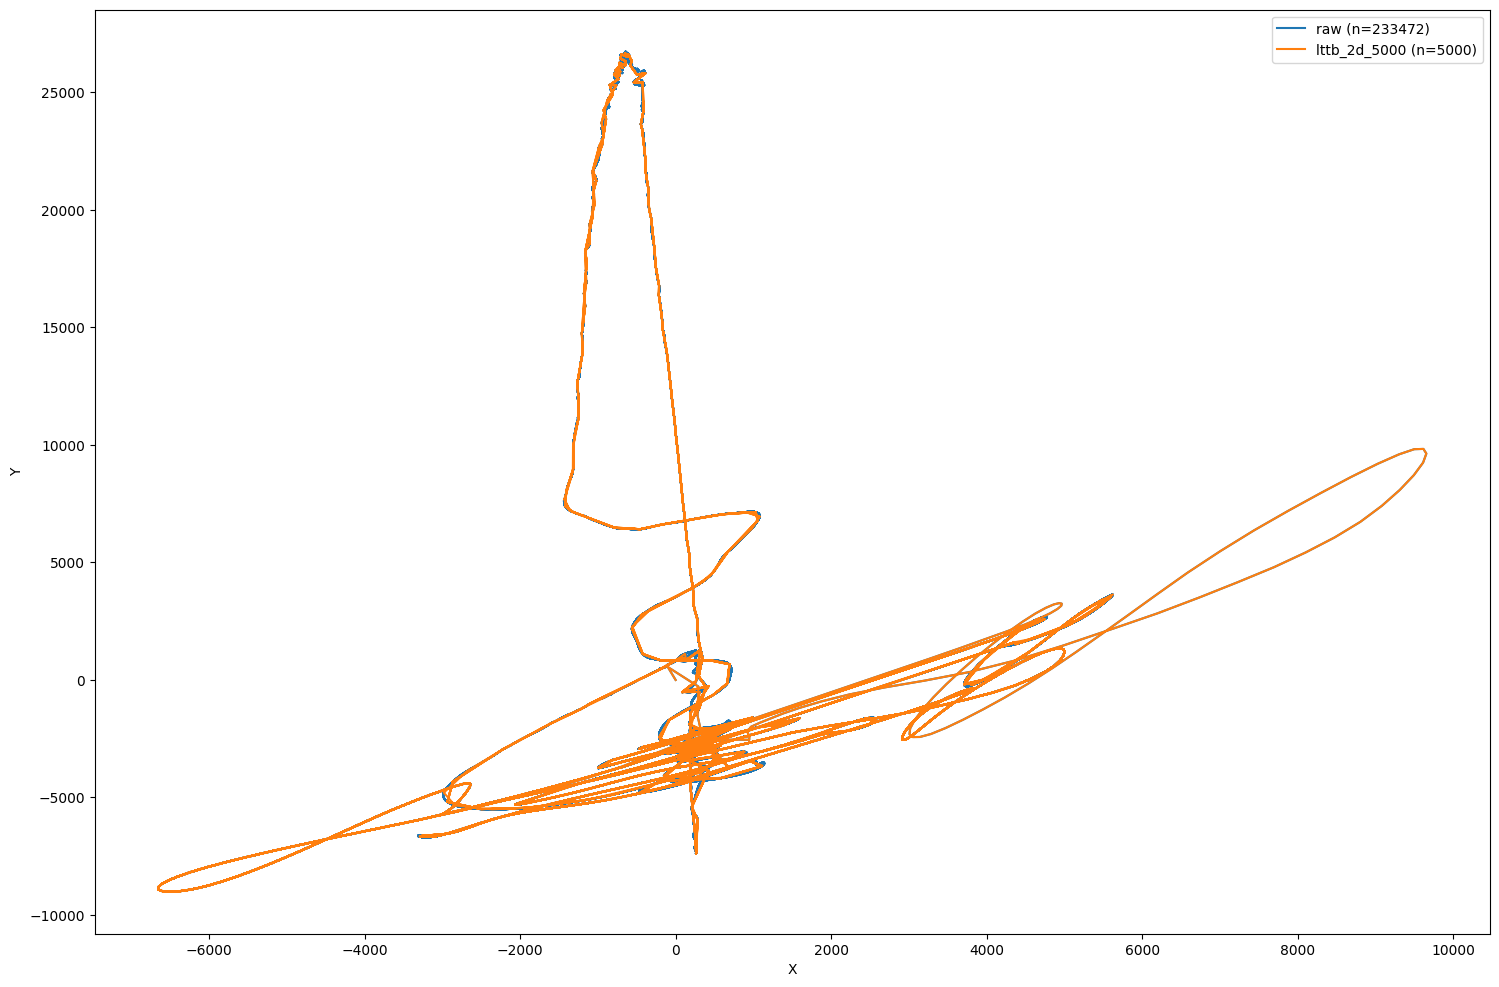

15.5648


In [13]:
from matplotlib import pyplot as plt
def plot_events(events):
    """
    Plot events from a dictionary of event data.

    Args:
        events: Dictionary of event data

    Returns:
        None
    """
    plt.figure(figsize=(18,12))  # Increased plot size
    for event_name, event_data in events.items():
        x = event_data[0]
        y = event_data[1]
        num_points = len(x)
        label_with_count = f"{event_name} (n={num_points})"
        plt.plot(x, y, label=label_with_count)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()
    

plot_events(events)
print(233472/15000)